# Notebook de dev pour l'entrainement vers MLflow

In [14]:
import logging
import numpy as np

import os
import mlflow
from mlflow import log_metric, log_param, log_artifacts
from random import random, randint
from datetime import datetime
import numpy as np

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
import time

from scipy.stats.mstats import winsorize

import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

import boto3


from dotenv import load_dotenv
load_dotenv(override=True)


True

In [15]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [45]:
mlflow.end_run()
# ====================== SÉCURITÉ MLFLOW POUR NOTEBOOK ======================
# partie spécifique dans les notebooks
if mlflow.active_run():
    mlflow.end_run()

# Force la fermeture de tous les runs actifs
while mlflow.active_run():
    mlflow.end_run()

print(" Tous les runs MLflow précédents ont été fermés.\n")
# ====================== CONFIGURATION MLFLOW ======================

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))

EXPERIMENT_NAME = "projet-retards-avion"

# Création + récupération de l'ID (plus fiable que set_experiment seul)
experiment = mlflow.set_experiment(EXPERIMENT_NAME)
experiment_id = experiment.experiment_id   # ou mlflow.get_experiment_by_name(EXPERIMENT_NAME).experiment_id

print(f"MLflow experiment : {EXPERIMENT_NAME} (ID: {experiment_id})\n")

# Forcer l'experiment actif avec l'ID
mlflow.set_experiment(experiment_id=experiment_id)



 Tous les runs MLflow précédents ont été fermés.

MLflow experiment : projet-retards-avion (ID: 407812594379366789)



<Experiment: artifact_location='mlflow-artifacts:/407812594379366789', creation_time=1779734436356, experiment_id='407812594379366789', last_update_time=1779734436356, lifecycle_stage='active', name='projet-retards-avion', tags={}>

# 1. Chargement des données

### Option 1. Via SQL

### Option 2. Via CSV

In [17]:
# On va lire un fichier depuis S3
def get_s3_parquet(s3_key):
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS"),
        region_name=os.getenv("AWS_DEFAULT_REGION_EQUIPE")
    )
    bucket = os.getenv("BUCKET")
    df= pd.read_parquet(f's3://{bucket}/{s3_key}')   
    return df



In [46]:
run_id="2026-05-25_124326_039dd1"

In [19]:
df_arr_raw = get_s3_parquet(f"projet_final_lead/processed/train/{run_id}/base_dataset_train_arrivals_{run_id}.parquet")
#on va lire un fichier parquet 
#df_ppml=pd.read_parquet("full_training_mouvements_aeroport_2025-11-22_to_2026-04-20.parquet")
#on va compter le nombre de lignes et de colonnes
print(f"Le dataset contient {df_arr_raw.shape[0]} lignes et {df_arr_raw.shape[1]} colonnes.")
df_arr_raw.columns

Le dataset contient 577933 lignes et 23 colonnes.


Index(['key', 'aeroport_depart', 'aeroport_arrivee', 'date', 'type',
       'arr_scheduled_utc', 'arr_revised_utc', 'arr_runway_utc',
       'arr_terminal', 'flight_number', 'callsign', 'status',
       'codeshare_status', 'is_cargo', 'aircraft_model', 'airline_icao',
       'meteo_temperature_2m', 'meteo_relative_humidity_2m',
       'meteo_wind_speed_10m', 'meteo_wind_gusts_10m', 'meteo_pressure_msl',
       'meteo_precipitation', 'meteo_cloud_cover'],
      dtype='object')

In [20]:
df_dep_raw = get_s3_parquet(f"projet_final_lead/processed/train/{run_id}/base_dataset_train_departures_{run_id}.parquet")
#on va lire un fichier parquet 
#df_ppml=pd.read_parquet("full_training_mouvements_aeroport_2025-11-22_to_2026-04-20.parquet")
#on va compter le nombre de lignes et de colonnes
print(f"Le dataset contient {df_dep_raw.shape[0]} lignes et {df_dep_raw.shape[1]} colonnes.")
df_dep_raw.columns

Le dataset contient 575827 lignes et 23 colonnes.


Index(['key', 'aeroport_depart', 'aeroport_arrivee', 'date', 'type',
       'dep_scheduled_utc', 'dep_revised_utc', 'dep_runway_utc',
       'dep_terminal', 'flight_number', 'callsign', 'status',
       'codeshare_status', 'is_cargo', 'aircraft_model', 'airline_icao',
       'meteo_temperature_2m', 'meteo_relative_humidity_2m',
       'meteo_wind_speed_10m', 'meteo_wind_gusts_10m', 'meteo_pressure_msl',
       'meteo_precipitation', 'meteo_cloud_cover'],
      dtype='object')


df_predict = get_s3_parquet("prod/predict/prediction_avril2026.parquet")

df_predict.columns

***

df_predict.scheduled_utc.min(), df_predict.scheduled_utc.max()

# 2. EDA initiale

### 1. Quelques stats

In [21]:
df_arr_raw.shape

(577933, 23)

In [22]:
df_dep_raw.shape

(575827, 23)

In [23]:
df_arr_raw.describe()


,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_wind_gusts_10m,meteo_pressure_msl,meteo_precipitation,meteo_cloud_cover
count,577933.000000,577933.000000,577933.000000,577933.000000,577933.000000,577933.000000,577933.000000
mean,8.748515,80.428750,11.340122,24.426177,1014.702933,0.087026,66.053985
std,5.400948,16.885663,5.857137,11.952158,9.990658,0.331269,41.716864
min,-7.400000,10.000000,0.000000,0.700000,975.200000,0.000000,0.000000
25%,5.500000,70.000000,7.100000,15.800000,1009.600000,0.000000,18.000000
50%,8.500000,86.000000,10.500000,22.700000,1017.100000,0.000000,97.000000
75%,11.800000,94.000000,15.100000,31.700000,1021.700000,0.000000,100.000000
max,30.300000,100.000000,49.900000,112.700000,1033.300000,17.500000,100.000000


In [24]:
df_arr_raw.dtypes

key                            object
aeroport_depart                object
aeroport_arrivee               object
date                           object
type                           object
arr_scheduled_utc              object
arr_revised_utc                object
arr_runway_utc                 object
arr_terminal                   object
flight_number                  object
callsign                       object
status                         object
codeshare_status               object
is_cargo                         bool
aircraft_model                 object
airline_icao                   object
meteo_temperature_2m          float64
meteo_relative_humidity_2m      int64
meteo_wind_speed_10m          float64
meteo_wind_gusts_10m          float64
meteo_pressure_msl            float64
meteo_precipitation           float64
meteo_cloud_cover               int64
dtype: object

***
STANDARDISATION DES COLONNES
on enleve les prefixes "arr_" et "dep_" pour unifier le travail

In [25]:
# def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
#     """Supprime les préfixes arr_ et dep_ des noms de colonnes"""
#     df = df.copy()
#     new_columns = {}
    
#     for col in df.columns:
#         if col.startswith("arr_"):
#             new_columns[col] = col.replace("arr_", "", 1)
#         elif col.startswith("dep_"):
#             new_columns[col] = col.replace("dep_", "", 1)
#         else:
#             new_columns[col] = col
    
#     df = df.rename(columns=new_columns)
#     return df

In [26]:
# df_arr_std= standardize_columns(df_arr_raw)
# df_dep_std= standardize_columns(df_dep_raw)
# print("Colonnes après standardisation :")
# print(df_arr_std.columns)
# print(df_dep_std.columns)

***
ANALYSE DES MANQUES ET NaN


In [27]:
def analyse_valeurs_manquantes(df: pd.DataFrame, name: str):
    print(f"\n=== Analyse des valeurs manquantes - {name} ===")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'missing_count': missing,
        'missing_percent': missing_percent.round(2)
    })
    
    # Ne garder que les colonnes qui ont des NaN
    missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_percent', ascending=False)
    
    print(missing_df)
    print(f"\nTotal colonnes avec NaN : {len(missing_df)}")
    print(f"Total colonnes : {len(df.columns)}")
    print(f"Total lignes : {len(df)}")
    return missing_df

In [28]:
analyse_valeurs_manquantes(df_arr_raw, "Arrivals")


=== Analyse des valeurs manquantes - Arrivals ===
                 missing_count  missing_percent
arr_runway_utc          569475            98.54
callsign                254536            44.04
arr_revised_utc          30785             5.33
airline_icao              5340             0.92
arr_terminal              3988             0.69
aircraft_model            2419             0.42
aeroport_depart           1211             0.21

Total colonnes avec NaN : 7
Total colonnes : 23
Total lignes : 577933


,missing_count,missing_percent
arr_runway_utc,569475,98.54
callsign,254536,44.04
arr_revised_utc,30785,5.33
airline_icao,5340,0.92
arr_terminal,3988,0.69
aircraft_model,2419,0.42
aeroport_depart,1211,0.21


In [29]:
analyse_valeurs_manquantes(df_dep_raw, "Departs")


=== Analyse des valeurs manquantes - Departs ===
                  missing_count  missing_percent
dep_runway_utc           429545            74.60
callsign                 268103            46.56
dep_revised_utc           22595             3.92
dep_terminal               7685             1.33
airline_icao               4317             0.75
aircraft_model             1744             0.30
aeroport_arrivee           1254             0.22

Total colonnes avec NaN : 7
Total colonnes : 23
Total lignes : 575827


,missing_count,missing_percent
dep_runway_utc,429545,74.60
callsign,268103,46.56
dep_revised_utc,22595,3.92
dep_terminal,7685,1.33
airline_icao,4317,0.75
aircraft_model,1744,0.30
aeroport_arrivee,1254,0.22


***
## NETTOYAGE

In [ ]:
import argparse
import pandas as pd
import io
from src.load_from import load_from_s3
from src.save_to import save_to_s3


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Supprime les préfixes arr_ et dep_"""
    df = df.copy()
    new_columns = {}
    for col in df.columns:
        if col.startswith("arr_"):
            new_columns[col] = col.replace("arr_", "", 1)
        elif col.startswith("dep_"):
            new_columns[col] = col.replace("dep_", "", 1)
        else:
            new_columns[col] = col
    return df.rename(columns=new_columns)


def clean_dataset(df: pd.DataFrame, is_future: bool = False) -> pd.DataFrame:
    """Nettoyage principal"""
    df = df.copy()
    
    if is_future:
        # === Pour données FUTURES ===
        initial = len(df)
        
        # 1. Garder uniquement les vols "Expected"
        df = df[df["status"] == "Expected"]
        
        # 2. Supprimer les lignes sans aéroport
        df = df.dropna(subset=["aeroport_depart", "aeroport_arrivee"])
        
        print(f"   - Lignes supprimées (status != Expected ou aéroport manquant) : {initial - len(df)}")
        
        # 3. Suppression des colonnes inutiles
        columns_to_drop = [
            "key", "date", "type", "callsign", "status", 
            "codeshare_status", "runway_utc", "revised_utc"
        ]
        
    else:
        # === Pour données HISTORIQUES ===
        initial = len(df)
        df = df.dropna(subset=["scheduled_utc", "revised_utc", "aeroport_arrivee", 
                               "aeroport_depart", "airline_icao"])
        print(f"   - Lignes supprimées (NaN) : {initial - len(df)}")
        
        columns_to_drop = [
            "key", "date", "type", "callsign", "status", 
            "codeshare_status", "runway_utc"
        ]
    
    # Suppression des colonnes
    existing_cols = [col for col in columns_to_drop if col in df.columns]
    df = df.drop(columns=existing_cols)
    
    return df


def filter_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Clip des outliers (uniquement historique)"""
    df = df.copy()
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce", utc=True)
    df["revised_utc"] = pd.to_datetime(df["revised_utc"], errors="coerce", utc=True)
    
    df["delay_minutes"] = (df["revised_utc"] - df["scheduled_utc"]).dt.total_seconds() / 60
    df["delay_minutes"] = df["delay_minutes"].clip(lower=-120, upper=180)
    
    print(f"   - Délais clippés entre -120 et +180 minutes")
    return df


def clean_data(run_id: str, is_future: bool = False):
    print(f"=== Nettoyage {'FUTUR' if is_future else 'HISTORIQUE'} - Run ID: {run_id} ===\n")
    
    folder = "prediction" if is_future else "train"
    prefix = "base_dataset_prediction" if is_future else "final"
    
    # === Arrivées ===
    print("→ Nettoyage Arrivées...")
    arrive_bytes = load_from_s3(f"processed/{folder}/{run_id}", 
                               f"{prefix}_arrivals_{run_id}.parquet")
    df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))
    
    df_arrive = standardize_columns(df_arrive)
    df_arrive = clean_dataset(df_arrive, is_future=is_future)
    if not is_future:
        df_arrive = filter_outliers(df_arrive)
    
    buffer = io.BytesIO()
    df_arrive.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", 
               f"clean_arrivals_{run_id}.parquet")
    print(f"   ✓ Arrivées nettoyées : {len(df_arrive)} lignes\n")
    
    # === Départs ===
    print("→ Nettoyage Départs...")
    depart_bytes = load_from_s3(f"processed/{folder}/{run_id}", 
                               f"{prefix}_departures_{run_id}.parquet")
    df_depart = pd.read_parquet(io.BytesIO(depart_bytes))
    
    df_depart = standardize_columns(df_depart)
    df_depart = clean_dataset(df_depart, is_future=is_future)
    if not is_future:
        df_depart = filter_outliers(df_depart)
    
    buffer = io.BytesIO()
    df_depart.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", 
               f"clean_departures_{run_id}.parquet")
    print(f"   ✓ Départs nettoyés : {len(df_depart)} lignes\n")
    
    print("=== Nettoyage terminé ===\n")


    
# USAGE clean_data(args.run_id, args.is_future)



In [36]:
clean_data(run_id)

=== Nettoyage - Run ID: 2026-05-25_124326_039dd1 ===

→ Nettoyage Arrivées...
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/base_dataset_train_arrivals_2026-05-25_124326_039dd1.parquet
   - Lignes supprimées (NaN) : 36356
   - Délais clippés entre -120 et +180 minutes
S3 -> projet_final_lead/processed/train/2026-05-25_124326_039dd1/clean_arrivals_2026-05-25_124326_039dd1.parquet
   ✓ Arrivées nettoyées : 541577 lignes

→ Nettoyage Départs...
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/base_dataset_train_departures_2026-05-25_124326_039dd1.parquet
   - Lignes supprimées (NaN) : 27334
   - Délais clippés entre -120 et +180 minutes
S3 -> projet_final_lead/processed/train/2026-05-25_124326_039dd1/clean_departures_2026-05-25_124326_039dd1.parquet
   ✓ Départs nettoyés : 548493 lignes

=== Nettoyage terminé ===



In [119]:
df_dep_clean.head()

,aeroport_depart,aeroport_arrivee,scheduled_utc,revised_utc,terminal,flight_number,is_cargo,aircraft_model,airline_icao,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_wind_gusts_10m,meteo_pressure_msl,meteo_precipitation,meteo_cloud_cover
0,LEMD,LFPG,2025-11-25 23:03:00+00:00,2025-11-25 23:03:00+00:00,None,3V 4VQ,True,Boeing 737-800,TAY,4.3,84,15.4,31.7,1014.7,0.0,20
1,LEMD,LFPG,2025-11-25 22:50:00+00:00,2025-11-25 23:12:00+00:00,3,IB 591,False,Airbus A320,IBE,4.3,84,15.4,31.7,1014.7,0.0,20
2,DAAG,LFPG,2025-11-25 21:05:00+00:00,2025-11-25 23:17:00+00:00,3,TO 7265,False,None,TVF,6.1,75,18.0,40.3,1012.2,0.0,20
3,LPPR,LFPG,2025-11-25 23:31:00+00:00,2025-11-25 23:31:00+00:00,None,3V 3PO,False,Boeing 737-400,TAY,4.2,82,16.9,32.0,1015.4,0.0,3
4,EGSS,LFPG,2025-11-25 23:32:00+00:00,2025-11-25 23:32:00+00:00,None,FX 5201,True,Boeing 767-300 Freighter,FDX,4.2,82,16.9,32.0,1015.4,0.0,3


In [121]:
df_dep_clean.dtypes

aeroport_depart                            object
aeroport_arrivee                           object
scheduled_utc                 datetime64[ns, UTC]
revised_utc                   datetime64[ns, UTC]
terminal                                   object
flight_number                              object
is_cargo                                     bool
aircraft_model                             object
airline_icao                               object
meteo_temperature_2m                      float64
meteo_relative_humidity_2m                  int64
meteo_wind_speed_10m                      float64
meteo_wind_gusts_10m                      float64
meteo_pressure_msl                        float64
meteo_precipitation                       float64
meteo_cloud_cover                           int64
dtype: object

In [122]:
analyse_valeurs_manquantes(df_dep_clean, "Departs")


=== Analyse des valeurs manquantes - Departs ===
                missing_count  missing_percent
terminal                 3103             0.57
aircraft_model           2329             0.43

Total colonnes avec NaN : 2
Total colonnes : 16
Total lignes : 541577


,missing_count,missing_percent
terminal,3103,0.57
aircraft_model,2329,0.43


In [123]:
analyse_valeurs_manquantes(df_arr_clean, "Arrivals")


=== Analyse des valeurs manquantes - Arrivals ===
                missing_count  missing_percent
terminal                 6425             1.17
aircraft_model           1582             0.29

Total colonnes avec NaN : 2
Total colonnes : 16
Total lignes : 548493


,missing_count,missing_percent
terminal,6425,1.17
aircraft_model,1582,0.29


***
## imputation des manques

In [37]:
import io
from src.load_from import load_from_s3
from src.save_to import save_to_s3

def impute_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute les valeurs manquantes restantes :
    - terminal → "Unknown"
    - aircraft_model → "Unknown"
    """
    df = df.copy()
    
    # Imputation
    df["terminal"] = df["terminal"].fillna("Unknown")
    df["aircraft_model"] = df["aircraft_model"].fillna("Unknown")
    
    # Vérification
    remaining_nan = df.isnull().sum().sum()
    print(f"   - Valeurs manquantes restantes après imputation : {remaining_nan}")
    
    return df

def impute_and_save(run_id: str):
    """Pipeline d'imputation complet"""
    print(f"=== Imputation des datasets - Run ID: {run_id} ===\n")
    
    # === Arrivées ===
    print("→ Imputation du dataset Arrivées...")
    arrive_bytes = load_from_s3(f"processed/train/{run_id}", f"clean_arrivals_{run_id}.parquet")
    df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))
    
    df_arrive = impute_missing_values(df_arrive)
    
    buffer = io.BytesIO()
    df_arrive.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/train/{run_id}", f"imputed_arrivals_{run_id}.parquet")
    print(f"   ✓ Arrivées imputées ({len(df_arrive)} lignes)\n")
    
    # === Départs ===
    print("→ Imputation du dataset Départs...")
    depart_bytes = load_from_s3(f"processed/train/{run_id}", f"clean_departures_{run_id}.parquet")
    df_depart = pd.read_parquet(io.BytesIO(depart_bytes))
    
    df_depart = impute_missing_values(df_depart)
    
    buffer = io.BytesIO()
    df_depart.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/train/{run_id}", f"imputed_departures_{run_id}.parquet")
    print(f"   ✓ Départs imputées ({len(df_depart)} lignes)\n")
    
    print(f"=== Imputation terminée ===")

In [38]:
impute_and_save(run_id)

=== Imputation des datasets - Run ID: 2026-05-25_124326_039dd1 ===

→ Imputation du dataset Arrivées...
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/clean_arrivals_2026-05-25_124326_039dd1.parquet
   - Valeurs manquantes restantes après imputation : 0
S3 -> projet_final_lead/processed/train/2026-05-25_124326_039dd1/imputed_arrivals_2026-05-25_124326_039dd1.parquet
   ✓ Arrivées imputées (541577 lignes)

→ Imputation du dataset Départs...
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/clean_departures_2026-05-25_124326_039dd1.parquet
   - Valeurs manquantes restantes après imputation : 0
S3 -> projet_final_lead/processed/train/2026-05-25_124326_039dd1/imputed_departures_2026-05-25_124326_039dd1.parquet
   ✓ Départs imputées (548493 lignes)

=== Imputation terminée ===


***
## feature engeenering

In [ ]:
import argparse
import pandas as pd
import io
import numpy as np
from datetime import datetime
import holidays
from vacances_scolaires_france import SchoolHolidayDates

from src.load_from import load_from_s3
from src.save_to import save_to_s3


def enrich_aircraft_features(df: pd.DataFrame) -> pd.DataFrame:
    """Version optimisée avec np.select()"""
    df = df.copy()
    f = df["aircraft_model"].fillna("Other").astype(str).str.upper().str.strip()

    conditions = [
        f.str.contains("A320|A319|A321|A318") & (f.str.contains("NEO|SHARKLETS")),
        f.str.contains("A320|A319|A321|A318"),
        f.str.contains("A350"),
        f.str.contains("A330"),
        f.str.contains("A380"),
        f.str.contains("A220|CS300"),
        f.str.contains("B737|737") & f.str.contains("MAX"),
        f.str.contains("B737|737"),
        f.str.contains("B777|777"),
        f.str.contains("B787|787"),
        f.str.contains("E190|E195|E170|E175|ERJ|EMB"),
        f.str.contains("ATR 72"),
        f.str.contains("ATR 42"),
        f.str.contains("CRJ"),
        f.str.contains("Q400|DHC-8"),
        f.str.contains("B767"),
        f.str.contains("B757"),
        f.str.contains("B747"),
    ]

    choices = [
        "Airbus A320 NEO", "Airbus A320 Family", "Airbus A350", "Airbus A330",
        "Airbus A380", "Airbus A220", "Boeing 737 MAX", "Boeing 737 Family",
        "Boeing 777", "Boeing 787", "Embraer E-Jet", "ATR 72", "ATR 42",
        "Bombardier CRJ", "Bombardier Dash 8 Q400", "Boeing 767", "Boeing 757", "Boeing 747"
    ]

    df["aircraft_family"] = np.select(conditions, choices, default="Other")

    seats_mapping = {
        "Airbus A320 Family": 165, "Airbus A320 NEO": 180, "Airbus A220": 135,
        "Boeing 737 Family": 155, "Boeing 737 MAX": 178, "Boeing 777": 355,
        "Boeing 787": 295, "Airbus A350": 325, "Airbus A330": 275,
        "Airbus A380": 525, "Embraer E-Jet": 100, "ATR 72": 68,
        "ATR 42": 48, "Bombardier CRJ": 85, "Bombardier Dash 8 Q400": 78,
        "Boeing 767": 260, "Boeing 757": 200, "Boeing 747": 410, "Other": 150,
    }

    df["num_seats"] = df["aircraft_family"].map(seats_mapping).fillna(150).astype(int)
    df["is_widebody"] = df["aircraft_family"].isin(["Airbus A330","Airbus A350","Airbus A380","Boeing 777","Boeing 787","Boeing 767","Boeing 747"])
    df["is_narrowbody"] = df["aircraft_family"].isin(["Airbus A320 Family","Airbus A220","Boeing 737 Family","Boeing 737 MAX","Embraer E-Jet"])
    df["is_regional"] = df["aircraft_family"].isin(["ATR 72","ATR 42","Bombardier CRJ","Bombardier Dash 8 Q400","Embraer E-Jet"])

    def get_size_category(family):
        if family in ["Airbus A380","Boeing 777","Boeing 787","Airbus A350","Boeing 747"]:
            return "Very Large"
        elif family in ["Airbus A330","Boeing 767"]:
            return "Large"
        elif family in ["Airbus A320 Family","Boeing 737 Family","Boeing 737 MAX","Airbus A220"]:
            return "Medium"
        else:
            return "Small"

    df["aircraft_size_category"] = df["aircraft_family"].apply(get_size_category)
    df["is_freighter"] = False

    return df


def add_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features jours fériés et vacances scolaires"""
    df = df.copy()
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce")
    df["flight_date"] = df["scheduled_utc"].dt.date

    fr_holidays = holidays.FR(years=range(2024, 2029))
    dte_schools = SchoolHolidayDates()

    df["is_holiday"] = df["flight_date"].apply(lambda x: 1 if x in fr_holidays else 0)
    df["vac_school"] = df["flight_date"].apply(lambda x: 1 if dte_schools.is_holiday(x) else 0)
    df["is_holiday_eve"] = df["flight_date"].apply(lambda x: 1 if (x + pd.Timedelta(days=1)) in fr_holidays else 0)
    df["is_holiday_next"] = df["flight_date"].apply(lambda x: 1 if (x - pd.Timedelta(days=1)) in fr_holidays else 0)
    df["is_weekend"] = df["scheduled_utc"].dt.dayofweek.isin([5, 6]).astype(int)
    df["is_weekend_or_holiday"] = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype(int)
    df["holiday_name"] = df["flight_date"].apply(lambda x: fr_holidays.get(x, "no_holiday"))

    df = df.drop(columns=["flight_date"], errors="ignore")
    return df


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features temporelles"""
    df = df.copy()
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce")

    df["hour"] = df["scheduled_utc"].dt.hour
    df["day_of_week"] = df["scheduled_utc"].dt.dayofweek
    df["month"] = df["scheduled_utc"].dt.month
    df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    df["is_morning_peak"] = df["hour"].isin([6, 7, 8, 9]).astype(int)
    df["is_evening_peak"] = df["hour"].isin([17, 18, 19, 20]).astype(int)

    return df


def feature_engineering(run_id: str, is_future: bool = False):
    mode = "FUTUR" if is_future else "TRAIN"
    folder = "prediction" if is_future else "train"
    prefix = "imputed"

    print(f"=== Feature Engineering {mode} - Run ID: {run_id} ===\n")

    for side in ["arrivals", "departures"]:
        print(f"→ {side.capitalize()}...")
        bytes_data = load_from_s3(f"processed/{folder}/{run_id}", f"{prefix}_{side}_{run_id}.parquet")
        df = pd.read_parquet(io.BytesIO(bytes_data))
        
        df = enrich_aircraft_features(df)
        df = add_holiday_features(df)
        df = add_temporal_features(df)

        buffer = io.BytesIO()
        df.to_parquet(buffer, index=False, compression="gzip")
        save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", f"final_{side}_{run_id}.parquet")
        print(f"   ✓ {side.capitalize()} : {len(df)} lignes\n")

    print(f"=== Feature Engineering {mode} terminé ===")



# USAGE: feature_engineering(args.run_id, args.is_future)

In [41]:
feature_engineering(run_id)

=== Feature Engineering - Run ID: 2026-05-25_124326_039dd1 ===

→ Arrivées...
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/imputed_arrivals_2026-05-25_124326_039dd1.parquet
S3 -> projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_arrivals_2026-05-25_124326_039dd1.parquet
   ✓ 541577 lignes

→ Départs...
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/imputed_departures_2026-05-25_124326_039dd1.parquet
S3 -> projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_departures_2026-05-25_124326_039dd1.parquet
   ✓ 548493 lignes

=== Feature Engineering terminé ===


CHECK UP

In [42]:
import pandas as pd
import io
from src.load_from import load_from_s3

run_id = "2026-05-25_124326_039dd1"

# === Arrivées ===
arrive_bytes = load_from_s3(f"processed/train/{run_id}", f"final_arrivals_{run_id}.parquet")
df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))

print("=== Colonnes Arrivées ===")
print(df_arrive.columns.tolist())
print(f"\nNombre de colonnes : {len(df_arrive.columns)}")
print(f"Nombre de lignes : {len(df_arrive)}")

# === Départs (optionnel) ===
depart_bytes = load_from_s3(f"processed/train/{run_id}", f"final_departures_{run_id}.parquet")
df_depart = pd.read_parquet(io.BytesIO(depart_bytes))
print("\n=== Colonnes Départs ===")
print(df_depart.columns.tolist())

S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_arrivals_2026-05-25_124326_039dd1.parquet
=== Colonnes Arrivées ===
['aeroport_depart', 'aeroport_arrivee', 'scheduled_utc', 'revised_utc', 'terminal', 'flight_number', 'is_cargo', 'aircraft_model', 'airline_icao', 'meteo_temperature_2m', 'meteo_relative_humidity_2m', 'meteo_wind_speed_10m', 'meteo_wind_gusts_10m', 'meteo_pressure_msl', 'meteo_precipitation', 'meteo_cloud_cover', 'delay_minutes', 'aircraft_family', 'num_seats', 'is_widebody', 'is_narrowbody', 'is_regional', 'aircraft_size_category', 'is_freighter', 'is_holiday', 'vac_school', 'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'is_weekend_or_holiday', 'holiday_name', 'hour', 'day_of_week', 'month', 'is_night', 'is_morning_peak', 'is_evening_peak']

Nombre de colonnes : 37
Nombre de lignes : 541577
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_departures_2026-05-25_124326_039dd1.parquet

=== Colonnes Départs ===
['aeroport_dep

In [43]:
df_arrive.head()

,aeroport_depart,aeroport_arrivee,scheduled_utc,revised_utc,terminal,flight_number,is_cargo,aircraft_model,airline_icao,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_wind_gusts_10m,meteo_pressure_msl,meteo_precipitation,meteo_cloud_cover,delay_minutes,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,hour,day_of_week,month,is_night,is_morning_peak,is_evening_peak
0,LEMD,LFPG,2025-11-25 23:03:00+00:00,2025-11-25 23:03:00+00:00,Unknown,3V 4VQ,True,Boeing 737-800,TAY,4.3,84,15.4,31.7,1014.7,0.0,20,0.0,Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,23,1,11,1,0,0
1,LEMD,LFPG,2025-11-25 22:50:00+00:00,2025-11-25 23:12:00+00:00,3,IB 591,False,Airbus A320,IBE,4.3,84,15.4,31.7,1014.7,0.0,20,22.0,Airbus A320 Family,165,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,22,1,11,1,0,0
2,DAAG,LFPG,2025-11-25 21:05:00+00:00,2025-11-25 23:17:00+00:00,3,TO 7265,False,Unknown,TVF,6.1,75,18.0,40.3,1012.2,0.0,20,132.0,Other,150,False,False,False,Small,False,0,0,0,0,0,0,No Holiday,21,1,11,0,0,0
3,LPPR,LFPG,2025-11-25 23:31:00+00:00,2025-11-25 23:31:00+00:00,Unknown,3V 3PO,False,Boeing 737-400,TAY,4.2,82,16.9,32.0,1015.4,0.0,3,0.0,Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,23,1,11,1,0,0
4,EGSS,LFPG,2025-11-25 23:32:00+00:00,2025-11-25 23:32:00+00:00,Unknown,FX 5201,True,Boeing 767-300 Freighter,FDX,4.2,82,16.9,32.0,1015.4,0.0,3,0.0,Other,150,False,False,False,Small,False,0,0,0,0,0,0,No Holiday,23,1,11,1,0,0


In [114]:
df_depart.head()

,aeroport_depart,aeroport_arrivee,scheduled_utc,revised_utc,terminal,flight_number,is_cargo,aircraft_model,airline_icao,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_wind_gusts_10m,meteo_pressure_msl,meteo_precipitation,meteo_cloud_cover,aircraft_family,num_seats,is_widebody,is_narrowbody,is_regional,aircraft_size_category,is_freighter,is_holiday,vac_school,is_holiday_eve,is_holiday_next,is_weekend,is_weekend_or_holiday,holiday_name,hour,day_of_week,month,is_night,is_morning_peak,is_evening_peak
0,LFPG,EGNX,2025-11-25 23:24:00+00:00,2025-11-25 23:24Z,Unknown,QY 6TL,False,Boeing 757-200,BCS,4.3,84,15.4,31.7,1014.7,0.0,20,Other,150,False,False,False,Small,False,0,0,0,0,0,0,No Holiday,23,1,11,1,0,0
1,LFPG,LFML,2025-11-26 00:43:00+00:00,2025-11-26 00:43Z,Unknown,5O 701,False,Boeing 737-400,FPO,4.0,87,16.6,32.4,1016.0,0.0,5,Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,0,2,11,1,0,0
2,LFPG,LFBO,2025-11-26 00:54:00+00:00,2025-11-26 00:54Z,Unknown,WT 5629,False,Boeing 737-800,SWT,4.0,87,16.6,32.4,1016.0,0.0,5,Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,0,2,11,1,0,0
3,LFPG,LFML,2025-11-26 01:19:00+00:00,2025-11-26 01:19Z,Unknown,WT 5745,False,Boeing 737-800,SWT,4.0,87,16.6,32.4,1016.0,0.0,5,Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,1,2,11,1,0,0
4,LFPG,EVRA,2025-11-26 02:48:00+00:00,2025-11-26 02:48Z,Unknown,3V 9IX,False,Boeing 737-800,TAY,3.5,91,15.8,31.0,1016.9,0.0,6,Boeing 737 Family,155,False,True,False,Medium,False,0,0,0,0,0,0,No Holiday,2,2,11,1,0,0


In [44]:
analyse_valeurs_manquantes(df_arrive, "Departs")


=== Analyse des valeurs manquantes - Departs ===
Empty DataFrame
Columns: [missing_count, missing_percent]
Index: []

Total colonnes avec NaN : 0
Total colonnes : 37
Total lignes : 541577


,missing_count,missing_percent


***
# TRAIN PIPELINE


In [47]:
import argparse
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor, Pool
import mlflow
import mlflow.catboost
import os
from dotenv import load_dotenv

from src.pipelines.custom_libs.load_from import load_from_s3

load_dotenv()

# ====================== CONFIGURATION MLFLOW ======================
mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI"))
mlflow.set_experiment("projet-retards-avion")

print(f"MLflow tracking URI : {mlflow.get_tracking_uri()}\n")


def prepare_data(df: pd.DataFrame) -> tuple:
    df = df.copy()
    
    # Conversion datetime
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce", utc=True)
    df["revised_utc"] = pd.to_datetime(df["revised_utc"], errors="coerce", utc=True)
    
    # Cible
    df["delay_minutes"] = (df["revised_utc"] - df["scheduled_utc"]).dt.total_seconds() / 60
    
    return df


def add_avg_delay_feature(df: pd.DataFrame, is_train: bool = True) -> pd.DataFrame:
    """Ajoute avg_delay_per_flight calculé uniquement sur le train"""
    df = df.copy()
    
    if is_train:
        # Calcul sur tout le dataset actuel (pour l'instant)
        avg_delay = df.groupby("flight_number")["delay_minutes"].mean().reset_index()
        avg_delay.columns = ["flight_number", "avg_delay_per_flight"]
        df = df.merge(avg_delay, on="flight_number", how="left")

        # === DEBUG : Affichage des exemples ===
        print(f"\nExemples de avg_delay_per_flight ({len(avg_delay)} vols uniques) :")
        sample = avg_delay.sample(n=min(10, len(avg_delay)), random_state=42)
        print(sample.round(2).to_string(index=False))
        
        # Statistiques globales
        print(f"Moyenne globale du délai moyen : {avg_delay['avg_delay_per_flight'].mean():.2f} minutes")
        print(f"Min / Max délai moyen         : {avg_delay['avg_delay_per_flight'].min():.2f} / {avg_delay['avg_delay_per_flight'].max():.2f} minutes")
    else:
        # Pour l'inférence future, on utilisera une table pré-calculée
        pass
    
    return df


def train_model(df, model_name: str, run_id: str):
    with mlflow.start_run(run_name=f"{model_name}_{run_id}") as run:
        
        print(f"\n=== Entraînement {model_name} ===")
        
        df = prepare_data(df)
        df = add_avg_delay_feature(df, is_train=True)
        
        # Features + Cible
        X = df.drop(columns=["scheduled_utc", "revised_utc", "flight_number", "delay_minutes"])
        y = df["delay_minutes"]
        
        X_train, X_val, y_train, y_val = train_test_split(
            X, y, test_size=0.20, random_state=42
        )
        
        cat_features = [
            "aeroport_depart", "aeroport_arrivee", "terminal", "airline_icao",
            "aircraft_model", "aircraft_family", "aircraft_size_category", 
            "holiday_name"
        ]
        
        train_pool = Pool(X_train, y_train, cat_features=cat_features)
        val_pool = Pool(X_val, y_val, cat_features=cat_features)
        
        model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=8,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=42,
            early_stopping_rounds=300,
            verbose=50,
            task_type='CPU',
            l2_leaf_reg=3,
            random_strength=1.0,
            bagging_temperature=0.7
        )
        
        model.fit(train_pool, eval_set=val_pool, use_best_model=True)
        
        # Évaluation
        preds = model.predict(X_val)
        mae = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2 = r2_score(y_val, preds)
        
        mlflow.log_metric("MAE", round(mae, 4))
        mlflow.log_metric("RMSE", round(rmse, 4))
        mlflow.log_metric("R2", round(r2, 4))
        mlflow.log_metric("best_iteration", model.get_best_iteration())
        
        print(f"\n=== Résultats {model_name} ===")
        print(f"MAE   : {mae:.3f} minutes")
        print(f"RMSE  : {rmse:.3f} minutes")
        print(f"R²    : {r2:.4f}")
        print(f"Best iteration : {model.get_best_iteration()}")
        print("="*60 + "\n")


def train_pipeline(run_id: str = None):
    if run_id is None:
        run_id = datetime.now().strftime("%Y-%m-%d_%H%M%S")
    
    print(f"=== Lancement du Train Pipeline - Run ID: {run_id} ===\n")
    
    # Départs
    depart_bytes = load_from_s3(f"processed/train/{run_id}", f"final_departures_{run_id}.parquet")
    df_depart = pd.read_parquet(io.BytesIO(depart_bytes))
    train_model(df_depart, "Departure", run_id)
    
    # Arrivées
    arrive_bytes = load_from_s3(f"processed/train/{run_id}", f"final_arrivals_{run_id}.parquet")
    df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))
    train_model(df_arrive, "Arrival", run_id)
    
    print(f"\n=== Train Pipeline terminé ===")



MLflow tracking URI : https://patjedhahf-mlflow-ppml.hf.space



In [48]:
train_pipeline(run_id)

=== Lancement du Train Pipeline - Run ID: 2026-05-25_124326_039dd1 ===

S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_departures_2026-05-25_124326_039dd1.parquet

=== Entraînement Departure ===

Exemples de avg_delay_per_flight (7699 vols uniques) :
flight_number  avg_delay_per_flight
      U2 2442                 23.81
       BA 351                 21.62
       TU 589                 32.84
      KQ 3066                 23.27
      F4 904P                  0.00
      U2 1623                 36.20
       AF 158                 47.56
      VY 8221                  6.72
      SV 6099                 28.25
      KL 2175                 43.71
Moyenne globale du délai moyen : 22.55 minutes
Min / Max délai moyen         : -31.00 / 631.00 minutes
0:	learn: 29.0850917	test: 29.5348256	best: 29.5348256 (0)	total: 478ms	remaining: 7m 57s
50:	learn: 25.6941289	test: 26.2825448	best: 26.2825448 (50)	total: 17.1s	remaining: 5m 18s
100:	learn: 25.2843703	test: 25.9266634	best

***

# DATASET PREDICTION ARRIVÉES

In [49]:
future_run_id="2026-05-25_221052_8f2d98"

In [51]:
df_pred_arr_raw = get_s3_parquet(f"projet_final_lead/processed/prediction/{future_run_id}/base_dataset_prediction_arrivals_{future_run_id}.parquet")

print(f"Le dataset contient {df_pred_arr_raw.shape[0]} lignes et {df_pred_arr_raw.shape[1]} colonnes.")
df_pred_arr_raw.columns

Le dataset contient 24490 lignes et 23 colonnes.


Index(['key', 'aeroport_depart', 'aeroport_arrivee', 'date', 'type',
       'arr_scheduled_utc', 'arr_revised_utc', 'arr_runway_utc',
       'arr_terminal', 'flight_number', 'callsign', 'status',
       'codeshare_status', 'is_cargo', 'aircraft_model', 'airline_icao',
       'meteo_temperature_2m', 'meteo_relative_humidity_2m',
       'meteo_wind_speed_10m', 'meteo_wind_gusts_10m', 'meteo_pressure_msl',
       'meteo_precipitation', 'meteo_cloud_cover'],
      dtype='object')

In [53]:
df_pred_dep_raw = get_s3_parquet(f"projet_final_lead/processed/prediction/{future_run_id}/base_dataset_prediction_departures_{future_run_id}.parquet")

print(f"Le dataset contient {df_pred_dep_raw.shape[0]} lignes et {df_pred_dep_raw.shape[1]} colonnes.")
df_pred_dep_raw.columns

Le dataset contient 24439 lignes et 23 colonnes.


Index(['key', 'aeroport_depart', 'aeroport_arrivee', 'date', 'type',
       'dep_scheduled_utc', 'dep_revised_utc', 'dep_runway_utc',
       'dep_terminal', 'flight_number', 'callsign', 'status',
       'codeshare_status', 'is_cargo', 'aircraft_model', 'airline_icao',
       'meteo_temperature_2m', 'meteo_relative_humidity_2m',
       'meteo_wind_speed_10m', 'meteo_wind_gusts_10m', 'meteo_pressure_msl',
       'meteo_precipitation', 'meteo_cloud_cover'],
      dtype='object')

In [57]:
df_pred_dep_raw.head()

,key,aeroport_depart,aeroport_arrivee,date,type,dep_scheduled_utc,dep_revised_utc,dep_runway_utc,dep_terminal,flight_number,callsign,status,codeshare_status,is_cargo,aircraft_model,airline_icao,meteo_temperature_2m,meteo_relative_humidity_2m,meteo_wind_speed_10m,meteo_wind_gusts_10m,meteo_pressure_msl,meteo_precipitation,meteo_cloud_cover
0,LFPG_2026-05-26,LFPG,BIKF,2026-05-26,departure,2026-05-26 04:00Z,2026-05-26 04:00Z,None,2D,EC 4629,None,Expected,IsCodeshared,False,Airbus A320,EJU,21.4,58,10.9,22.3,1029.1,0.0,0
1,LFPG_2026-05-26,LFPG,BIKF,2026-05-26,departure,2026-05-26 04:00Z,2026-05-26 04:00Z,None,2D,U2 4629,None,Expected,IsOperator,False,Airbus A320,EZY,21.4,58,10.9,22.3,1029.1,0.0,0
2,LFPG_2026-05-26,LFPG,LEMD,2026-05-26,departure,2026-05-26 04:00Z,2026-05-26 04:00Z,None,3,IB 592,None,Expected,IsOperator,False,Airbus A320,IBE,21.4,58,10.9,22.3,1029.1,0.0,0
3,LFPG_2026-05-26,LFPG,LIMC,2026-05-26,departure,2026-05-26 04:00Z,2026-05-26 04:00Z,None,2D,EC 4541,None,Expected,IsCodeshared,False,Airbus A320,EJU,21.4,58,10.9,22.3,1029.1,0.0,0
4,LFPG_2026-05-26,LFPG,LIMC,2026-05-26,departure,2026-05-26 04:00Z,2026-05-26 04:00Z,None,2D,U2 4541,None,Expected,IsOperator,False,Airbus A320,EZY,21.4,58,10.9,22.3,1029.1,0.0,0


***
## NETTOYAGE

In [63]:
import argparse
import pandas as pd
import io
from src.load_from import load_from_s3
from src.save_to import save_to_s3


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Supprime les préfixes arr_ et dep_"""
    df = df.copy()
    new_columns = {}
    for col in df.columns:
        if col.startswith("arr_"):
            new_columns[col] = col.replace("arr_", "", 1)
        elif col.startswith("dep_"):
            new_columns[col] = col.replace("dep_", "", 1)
        else:
            new_columns[col] = col
    return df.rename(columns=new_columns)


def clean_dataset(df: pd.DataFrame, is_future: bool = False) -> pd.DataFrame:
    """Nettoyage principal"""
    df = df.copy()
    
    if is_future:
        # === Pour données FUTURES ===
        initial = len(df)
        
        # 1. Garder uniquement les vols "Expected"
        df = df[df["status"] == "Expected"]
        
        # 2. Supprimer les lignes sans aéroport
        df = df.dropna(subset=["aeroport_depart", "aeroport_arrivee"])
        
        print(f"   - Lignes supprimées (status != Expected ou aéroport manquant) : {initial - len(df)}")
        
        # 3. Suppression des colonnes inutiles
        columns_to_drop = [
            "key", "date", "type", "callsign", "status", 
            "codeshare_status", "runway_utc", "revised_utc"
        ]
        
    else:
        # === Pour données HISTORIQUES ===
        initial = len(df)
        df = df.dropna(subset=["scheduled_utc", "revised_utc", "aeroport_arrivee", 
                               "aeroport_depart", "airline_icao"])
        print(f"   - Lignes supprimées (NaN) : {initial - len(df)}")
        
        columns_to_drop = [
            "key", "date", "type", "callsign", "status", 
            "codeshare_status", "runway_utc"
        ]
    
    # Suppression des colonnes
    existing_cols = [col for col in columns_to_drop if col in df.columns]
    df = df.drop(columns=existing_cols)
    
    return df


def filter_outliers(df: pd.DataFrame) -> pd.DataFrame:
    """Clip des outliers (uniquement historique)"""
    df = df.copy()
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce", utc=True)
    df["revised_utc"] = pd.to_datetime(df["revised_utc"], errors="coerce", utc=True)
    
    df["delay_minutes"] = (df["revised_utc"] - df["scheduled_utc"]).dt.total_seconds() / 60
    df["delay_minutes"] = df["delay_minutes"].clip(lower=-120, upper=180)
    
    print(f"   - Délais clippés entre -120 et +180 minutes")
    return df


def clean_data(run_id: str, is_future: bool = False):
    print(f"=== Nettoyage {'FUTUR' if is_future else 'HISTORIQUE'} - Run ID: {run_id} ===\n")
    
    folder = "prediction" if is_future else "train"
    prefix = "base_dataset_prediction" if is_future else "final"
    
    # === Arrivées ===
    print("→ Nettoyage Arrivées...")
    arrive_bytes = load_from_s3(f"processed/{folder}/{run_id}", 
                               f"{prefix}_arrivals_{run_id}.parquet")
    df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))
    
    df_arrive = standardize_columns(df_arrive)
    df_arrive = clean_dataset(df_arrive, is_future=is_future)
    if not is_future:
        df_arrive = filter_outliers(df_arrive)
    
    buffer = io.BytesIO()
    df_arrive.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", 
               f"clean_arrivals_{run_id}.parquet")
    print(f"   ✓ Arrivées nettoyées : {len(df_arrive)} lignes\n")
    
    # === Départs ===
    print("→ Nettoyage Départs...")
    depart_bytes = load_from_s3(f"processed/{folder}/{run_id}", 
                               f"{prefix}_departures_{run_id}.parquet")
    df_depart = pd.read_parquet(io.BytesIO(depart_bytes))
    
    df_depart = standardize_columns(df_depart)
    df_depart = clean_dataset(df_depart, is_future=is_future)
    if not is_future:
        df_depart = filter_outliers(df_depart)
    
    buffer = io.BytesIO()
    df_depart.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", 
               f"clean_departures_{run_id}.parquet")
    print(f"   ✓ Départs nettoyés : {len(df_depart)} lignes\n")
    
    print("=== Nettoyage terminé ===\n")


    
# USAGE clean_data(args.run_id, args.is_future)



In [64]:
clean_data("2026-05-25_221052_8f2d98", True)

=== Nettoyage FUTUR - Run ID: 2026-05-25_221052_8f2d98 ===

→ Nettoyage Arrivées...
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/base_dataset_prediction_arrivals_2026-05-25_221052_8f2d98.parquet
   - Lignes supprimées (status != Expected ou aéroport manquant) : 95
S3 -> projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/clean_arrivals_2026-05-25_221052_8f2d98.parquet
   ✓ Arrivées nettoyées : 24395 lignes

→ Nettoyage Départs...
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/base_dataset_prediction_departures_2026-05-25_221052_8f2d98.parquet
   - Lignes supprimées (status != Expected ou aéroport manquant) : 65
S3 -> projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/clean_departures_2026-05-25_221052_8f2d98.parquet
   ✓ Départs nettoyés : 24374 lignes

=== Nettoyage terminé ===



CHECK des manques dans les datasets de prediction

In [65]:
import pandas as pd
import io
from src.load_from import load_from_s3

run_id = "2026-05-25_221052_8f2d98"

# === Chargement des datasets nettoyés ===
print(f"=== Analyse des valeurs manquantes - Run ID: {run_id} ===\n")

# Arrivées
arrive_bytes = load_from_s3(f"processed/prediction/{run_id}", f"clean_arrivals_{run_id}.parquet")
df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))

# Départs
depart_bytes = load_from_s3(f"processed/prediction/{run_id}", f"clean_departures_{run_id}.parquet")
df_depart = pd.read_parquet(io.BytesIO(depart_bytes))

# === Analyse Arrivées ===
print("=== Arrivées ===")
missing_arr = df_arrive.isnull().sum()
missing_arr = missing_arr[missing_arr > 0].sort_values(ascending=False)
if len(missing_arr) > 0:
    print(missing_arr)
    print(f"\nTotal colonnes avec NaN : {len(missing_arr)}")
else:
    print("Aucune valeur manquante !")
print(f"Total lignes : {len(df_arrive)}\n")
print("shape Arrivées :", df_arrive.shape)

# === Analyse Départs ===
print("=== Départs ===")
missing_dep = df_depart.isnull().sum()
missing_dep = missing_dep[missing_dep > 0].sort_values(ascending=False)
if len(missing_dep) > 0:
    print(missing_dep)
    print(f"\nTotal colonnes avec NaN : {len(missing_dep)}")
else:
    print("Aucune valeur manquante !")
print(f"Total lignes : {len(df_depart)}\n")
print("shape Départs :", df_depart.shape)

=== Analyse des valeurs manquantes - Run ID: 2026-05-25_221052_8f2d98 ===

S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/clean_arrivals_2026-05-25_221052_8f2d98.parquet
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/clean_departures_2026-05-25_221052_8f2d98.parquet
=== Arrivées ===
airline_icao      207
aircraft_model    104
terminal           68
dtype: int64

Total colonnes avec NaN : 3
Total lignes : 24395

shape Arrivées : (24395, 15)
=== Départs ===
airline_icao      152
aircraft_model     84
terminal           28
dtype: int64

Total colonnes avec NaN : 3
Total lignes : 24374

shape Départs : (24374, 15)


In [66]:
import argparse
import pandas as pd
import io
from src.load_from import load_from_s3
from src.save_to import save_to_s3


def impute_future_data(df: pd.DataFrame) -> pd.DataFrame:
    """Imputation pour données futures"""
    df = df.copy()
    
    # Imputation simple et sûre
    df["terminal"] = df["terminal"].fillna("Unknown")
    df["aircraft_model"] = df["aircraft_model"].fillna("Unknown")
    df["airline_icao"] = df["airline_icao"].fillna("Unknown")
    
    remaining = df.isnull().sum().sum()
    print(f"   - Valeurs manquantes restantes après imputation : {remaining}")
    
    return df


def impute_data(run_id: str, is_future: bool = False):
    mode = "FUTUR" if is_future else "HISTORIQUE"
    print(f"=== Imputation {mode} - Run ID: {run_id} ===\n")
    
    folder = "prediction" if is_future else "train"
    prefix = "clean"
    
    # === Arrivées ===
    print("→ Imputation Arrivées...")
    arrive_bytes = load_from_s3(f"processed/{folder}/{run_id}", f"{prefix}_arrivals_{run_id}.parquet")
    df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))
    
    df_arrive = impute_future_data(df_arrive)
    
    buffer = io.BytesIO()
    df_arrive.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", f"imputed_arrivals_{run_id}.parquet")
    print(f"   ✓ Arrivées imputées : {len(df_arrive)} lignes\n")
    
    # === Départs ===
    print("→ Imputation Départs...")
    depart_bytes = load_from_s3(f"processed/{folder}/{run_id}", f"{prefix}_departures_{run_id}.parquet")
    df_depart = pd.read_parquet(io.BytesIO(depart_bytes))
    
    df_depart = impute_future_data(df_depart)
    
    buffer = io.BytesIO()
    df_depart.to_parquet(buffer, index=False, compression="gzip")
    save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", f"imputed_departures_{run_id}.parquet")
    print(f"   ✓ Départs imputés : {len(df_depart)} lignes\n")
    
    print("=== Imputation terminée ===\n")


#usage impute_data(args.run_id, args.is_future)

In [67]:
impute_data("2026-05-25_221052_8f2d98", True)

=== Imputation FUTUR - Run ID: 2026-05-25_221052_8f2d98 ===

→ Imputation Arrivées...
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/clean_arrivals_2026-05-25_221052_8f2d98.parquet
   - Valeurs manquantes restantes après imputation : 0
S3 -> projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/imputed_arrivals_2026-05-25_221052_8f2d98.parquet
   ✓ Arrivées imputées : 24395 lignes

→ Imputation Départs...
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/clean_departures_2026-05-25_221052_8f2d98.parquet
   - Valeurs manquantes restantes après imputation : 0
S3 -> projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/imputed_departures_2026-05-25_221052_8f2d98.parquet
   ✓ Départs imputés : 24374 lignes

=== Imputation terminée ===



CHECK apres IMPUTATION 

In [68]:
import pandas as pd
import io
from src.load_from import load_from_s3

run_id = "2026-05-25_221052_8f2d98"

# === Chargement des datasets nettoyés ===
print(f"=== Analyse des valeurs manquantes - Run ID: {run_id} ===\n")

# Arrivées
arrive_bytes = load_from_s3(f"processed/prediction/{run_id}", f"imputed_arrivals_{run_id}.parquet")
df_arrive = pd.read_parquet(io.BytesIO(arrive_bytes))

# Départs
depart_bytes = load_from_s3(f"processed/prediction/{run_id}", f"imputed_departures_{run_id}.parquet")
df_depart = pd.read_parquet(io.BytesIO(depart_bytes))

# === Analyse Arrivées ===
print("=== Arrivées ===")
missing_arr = df_arrive.isnull().sum()
missing_arr = missing_arr[missing_arr > 0].sort_values(ascending=False)
if len(missing_arr) > 0:
    print(missing_arr)
    print(f"\nTotal colonnes avec NaN : {len(missing_arr)}")
else:
    print("Aucune valeur manquante !")
print(f"Total lignes : {len(df_arrive)}\n")
print("shape Arrivées :", df_arrive.shape)

# === Analyse Départs ===
print("=== Départs ===")
missing_dep = df_depart.isnull().sum()
missing_dep = missing_dep[missing_dep > 0].sort_values(ascending=False)
if len(missing_dep) > 0:
    print(missing_dep)
    print(f"\nTotal colonnes avec NaN : {len(missing_dep)}")
else:
    print("Aucune valeur manquante !")
print(f"Total lignes : {len(df_depart)}\n")
print("shape Départs :", df_depart.shape)

=== Analyse des valeurs manquantes - Run ID: 2026-05-25_221052_8f2d98 ===

S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/imputed_arrivals_2026-05-25_221052_8f2d98.parquet
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/imputed_departures_2026-05-25_221052_8f2d98.parquet
=== Arrivées ===
Aucune valeur manquante !
Total lignes : 24395

shape Arrivées : (24395, 15)
=== Départs ===
Aucune valeur manquante !
Total lignes : 24374

shape Départs : (24374, 15)


***
## FEATURES

In [69]:
import argparse
import pandas as pd
import io
import numpy as np
from datetime import datetime
import holidays
from vacances_scolaires_france import SchoolHolidayDates

from src.load_from import load_from_s3
from src.save_to import save_to_s3


def enrich_aircraft_features(df: pd.DataFrame) -> pd.DataFrame:
    """Version optimisée avec np.select()"""
    df = df.copy()
    f = df["aircraft_model"].fillna("Other").astype(str).str.upper().str.strip()

    conditions = [
        f.str.contains("A320|A319|A321|A318") & (f.str.contains("NEO|SHARKLETS")),
        f.str.contains("A320|A319|A321|A318"),
        f.str.contains("A350"),
        f.str.contains("A330"),
        f.str.contains("A380"),
        f.str.contains("A220|CS300"),
        f.str.contains("B737|737") & f.str.contains("MAX"),
        f.str.contains("B737|737"),
        f.str.contains("B777|777"),
        f.str.contains("B787|787"),
        f.str.contains("E190|E195|E170|E175|ERJ|EMB"),
        f.str.contains("ATR 72"),
        f.str.contains("ATR 42"),
        f.str.contains("CRJ"),
        f.str.contains("Q400|DHC-8"),
        f.str.contains("B767"),
        f.str.contains("B757"),
        f.str.contains("B747"),
    ]

    choices = [
        "Airbus A320 NEO", "Airbus A320 Family", "Airbus A350", "Airbus A330",
        "Airbus A380", "Airbus A220", "Boeing 737 MAX", "Boeing 737 Family",
        "Boeing 777", "Boeing 787", "Embraer E-Jet", "ATR 72", "ATR 42",
        "Bombardier CRJ", "Bombardier Dash 8 Q400", "Boeing 767", "Boeing 757", "Boeing 747"
    ]

    df["aircraft_family"] = np.select(conditions, choices, default="Other")

    seats_mapping = {
        "Airbus A320 Family": 165, "Airbus A320 NEO": 180, "Airbus A220": 135,
        "Boeing 737 Family": 155, "Boeing 737 MAX": 178, "Boeing 777": 355,
        "Boeing 787": 295, "Airbus A350": 325, "Airbus A330": 275,
        "Airbus A380": 525, "Embraer E-Jet": 100, "ATR 72": 68,
        "ATR 42": 48, "Bombardier CRJ": 85, "Bombardier Dash 8 Q400": 78,
        "Boeing 767": 260, "Boeing 757": 200, "Boeing 747": 410, "Other": 150,
    }

    df["num_seats"] = df["aircraft_family"].map(seats_mapping).fillna(150).astype(int)
    df["is_widebody"] = df["aircraft_family"].isin(["Airbus A330","Airbus A350","Airbus A380","Boeing 777","Boeing 787","Boeing 767","Boeing 747"])
    df["is_narrowbody"] = df["aircraft_family"].isin(["Airbus A320 Family","Airbus A220","Boeing 737 Family","Boeing 737 MAX","Embraer E-Jet"])
    df["is_regional"] = df["aircraft_family"].isin(["ATR 72","ATR 42","Bombardier CRJ","Bombardier Dash 8 Q400","Embraer E-Jet"])

    def get_size_category(family):
        if family in ["Airbus A380","Boeing 777","Boeing 787","Airbus A350","Boeing 747"]:
            return "Very Large"
        elif family in ["Airbus A330","Boeing 767"]:
            return "Large"
        elif family in ["Airbus A320 Family","Boeing 737 Family","Boeing 737 MAX","Airbus A220"]:
            return "Medium"
        else:
            return "Small"

    df["aircraft_size_category"] = df["aircraft_family"].apply(get_size_category)
    df["is_freighter"] = False

    return df


def add_holiday_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features jours fériés et vacances scolaires"""
    df = df.copy()
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce")
    df["flight_date"] = df["scheduled_utc"].dt.date

    fr_holidays = holidays.FR(years=range(2024, 2029))
    dte_schools = SchoolHolidayDates()

    df["is_holiday"] = df["flight_date"].apply(lambda x: 1 if x in fr_holidays else 0)
    df["vac_school"] = df["flight_date"].apply(lambda x: 1 if dte_schools.is_holiday(x) else 0)
    df["is_holiday_eve"] = df["flight_date"].apply(lambda x: 1 if (x + pd.Timedelta(days=1)) in fr_holidays else 0)
    df["is_holiday_next"] = df["flight_date"].apply(lambda x: 1 if (x - pd.Timedelta(days=1)) in fr_holidays else 0)
    df["is_weekend"] = df["scheduled_utc"].dt.dayofweek.isin([5, 6]).astype(int)
    df["is_weekend_or_holiday"] = ((df["is_weekend"] == 1) | (df["is_holiday"] == 1)).astype(int)
    df["holiday_name"] = df["flight_date"].apply(lambda x: fr_holidays.get(x, "no_holiday"))

    df = df.drop(columns=["flight_date"], errors="ignore")
    return df


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Features temporelles"""
    df = df.copy()
    df["scheduled_utc"] = pd.to_datetime(df["scheduled_utc"], errors="coerce")

    df["hour"] = df["scheduled_utc"].dt.hour
    df["day_of_week"] = df["scheduled_utc"].dt.dayofweek
    df["month"] = df["scheduled_utc"].dt.month
    df["is_night"] = df["hour"].isin([22, 23, 0, 1, 2, 3, 4, 5]).astype(int)
    df["is_morning_peak"] = df["hour"].isin([6, 7, 8, 9]).astype(int)
    df["is_evening_peak"] = df["hour"].isin([17, 18, 19, 20]).astype(int)

    return df


def feature_engineering(run_id: str, is_future: bool = False):
    mode = "FUTUR" if is_future else "TRAIN"
    folder = "prediction" if is_future else "train"
    prefix = "imputed"

    print(f"=== Feature Engineering {mode} - Run ID: {run_id} ===\n")

    for side in ["arrivals", "departures"]:
        print(f"→ {side.capitalize()}...")
        bytes_data = load_from_s3(f"processed/{folder}/{run_id}", f"{prefix}_{side}_{run_id}.parquet")
        df = pd.read_parquet(io.BytesIO(bytes_data))
        
        df = enrich_aircraft_features(df)
        df = add_holiday_features(df)
        df = add_temporal_features(df)

        buffer = io.BytesIO()
        df.to_parquet(buffer, index=False, compression="gzip")
        save_to_s3(buffer.getvalue(), f"processed/{folder}/{run_id}", f"final_{side}_{run_id}.parquet")
        print(f"   ✓ {side.capitalize()} : {len(df)} lignes\n")

    print(f"=== Feature Engineering {mode} terminé ===")


# USAGE feature_engineering(args.run_id, args.is_future) ex run_id future = 2026-05-25_221052_8f2d98

In [70]:
feature_engineering("2026-05-25_221052_8f2d98", True)

=== Feature Engineering FUTUR - Run ID: 2026-05-25_221052_8f2d98 ===

→ Arrivals...
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/imputed_arrivals_2026-05-25_221052_8f2d98.parquet
S3 -> projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/final_arrivals_2026-05-25_221052_8f2d98.parquet
   ✓ Arrivals : 24395 lignes

→ Departures...
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/imputed_departures_2026-05-25_221052_8f2d98.parquet
S3 -> projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/final_departures_2026-05-25_221052_8f2d98.parquet
   ✓ Departures : 24374 lignes

=== Feature Engineering FUTUR terminé ===


CHECK FINAL

In [89]:
import pandas as pd
import io
from src.load_from import load_from_s3

run_id_train = "2026-05-25_124326_039dd1"
run_id_pred  = "2026-05-25_221052_8f2d98"

# Chargement
df_arrive_train = pd.read_parquet(io.BytesIO(
    load_from_s3(f"processed/train/{run_id_train}", f"final_arrivals_{run_id_train}.parquet")
))

df_depart_train = pd.read_parquet(io.BytesIO(
    load_from_s3(f"processed/train/{run_id_train}", f"final_departures_{run_id_train}.parquet")
))

df_arrive_pred = pd.read_parquet(io.BytesIO(
    load_from_s3(f"processed/prediction/{run_id_pred}", f"final_arrivals_{run_id_pred}.parquet")
))

df_depart_pred = pd.read_parquet(io.BytesIO(
    load_from_s3(f"processed/prediction/{run_id_pred}", f"final_departures_{run_id_pred}.parquet")
))

# ====================== COMPARAISON ======================
print("=== COMPARAISON COLONNES Train vs Prediction ===\n")

print(f"Train Arrivées  : {len(df_arrive_train.columns)} colonnes")
print(f"Train Départs   : {len(df_depart_train.columns)} colonnes")
print(f"Pred Arrivées   : {len(df_arrive_pred.columns)} colonnes")
print(f"Pred Départs    : {len(df_depart_pred.columns)} colonnes\n")

common = set(df_arrive_train.columns) & set(df_arrive_pred.columns)
only_train = set(df_arrive_train.columns) - set(df_arrive_pred.columns)
only_pred  = set(df_arrive_pred.columns) - set(df_arrive_train.columns)

print("Colonnes communes :", sorted(common))
print(f"→ Total communes : {len(common)}\n")

print("Colonnes UNIQUEMENT dans Train :", sorted(only_train))
print("Colonnes UNIQUEMENT dans Prediction :", sorted(only_pred))

S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_arrivals_2026-05-25_124326_039dd1.parquet
S3 <- projet_final_lead/processed/train/2026-05-25_124326_039dd1/final_departures_2026-05-25_124326_039dd1.parquet
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/final_arrivals_2026-05-25_221052_8f2d98.parquet
S3 <- projet_final_lead/processed/prediction/2026-05-25_221052_8f2d98/final_departures_2026-05-25_221052_8f2d98.parquet
=== COMPARAISON COLONNES Train vs Prediction ===

Train Arrivées  : 37 colonnes
Train Départs   : 37 colonnes
Pred Arrivées   : 35 colonnes
Pred Départs    : 35 colonnes

Colonnes communes : ['aeroport_arrivee', 'aeroport_depart', 'aircraft_family', 'aircraft_model', 'aircraft_size_category', 'airline_icao', 'day_of_week', 'flight_number', 'holiday_name', 'hour', 'is_cargo', 'is_evening_peak', 'is_freighter', 'is_holiday', 'is_holiday_eve', 'is_holiday_next', 'is_morning_peak', 'is_narrowbody', 'is_night', 'is_regional', 'is_wee

*** 
VISUALISATIONS

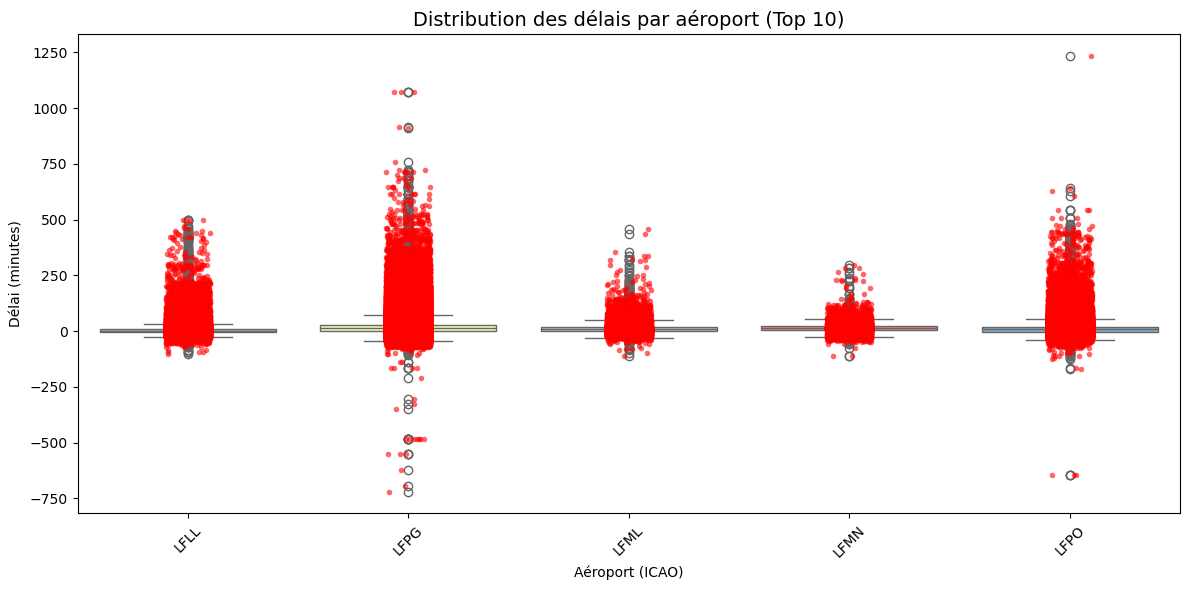

In [43]:
# Graphique des délais par aéroport (Top 10)
top_airports = df_ppml['icao'].value_counts().head(10).index

plt.figure(figsize=(12, 6))

sns.boxplot(data=df_ppml[df_ppml['icao'].isin(top_airports)], 
            x='icao', 
            y='delay_minutes',          # ou 'delay_minutes_clean' selon ton df
            hue='icao',                 # ← AJOUTÉ
            palette="Set3",
            legend=False)               # ← AJOUTÉ

sns.stripplot(data=df_ppml[df_ppml['icao'].isin(top_airports)], 
              x='icao', 
              y='delay_minutes',
              color='red', 
              size=4, 
              alpha=0.6, 
              jitter=True)

plt.title("Distribution des délais par aéroport (Top 10)", fontsize=14)
plt.ylabel("Délai (minutes)")
plt.xlabel("Aéroport (ICAO)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

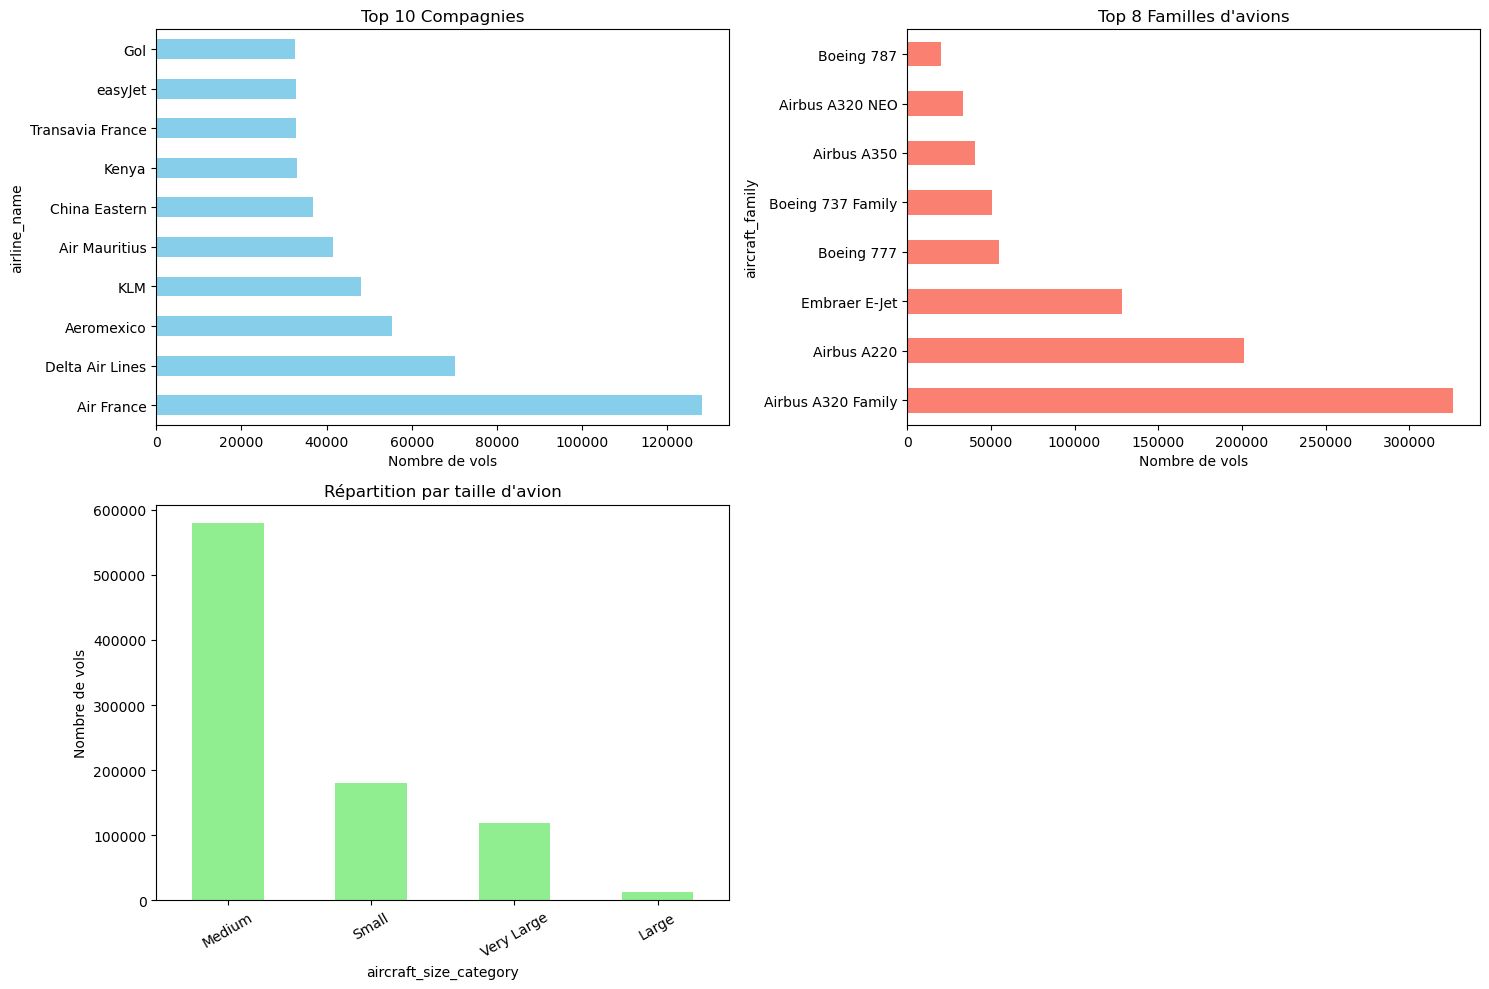

In [44]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
df_fe['airline_name'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title("Top 10 Compagnies")
plt.xlabel("Nombre de vols")

plt.subplot(2, 2, 2)
df_fe['aircraft_family'].value_counts().head(8).plot(kind='barh', color='salmon')
plt.title("Top 8 Familles d'avions")
plt.xlabel("Nombre de vols")

plt.subplot(2, 2, 3)
df_fe['aircraft_size_category'].value_counts().plot(kind='bar', color='lightgreen')
plt.title("Répartition par taille d'avion")
plt.ylabel("Nombre de vols")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### petit test de prediction en local avec le dataset de prediction

In [ ]:
def make_predictions(df_pred_raw, output_filename="predictions_result.csv", model=None, te=None):
    """
    Prépare le df_pred et retourne les prédictions.
    """
    df = df_pred_raw.copy()
    
    print(f"Dataset de départ : {df.shape[0]} lignes")
    
   # Attention le dataset de predict doit etre préparé de maniere a etre ISO avec le dataset d'entrainement (meme features, meme preprocessing) 
   # pour que le modèle puisse faire des prédictions correctes*
    # ====================== TARGET ENCODING ======================
    high_card_cols = ['airline_name', 'dest_icao_clean', 'aircraft_model']
    
    print("Application du TargetEncoder...")
    X_pred = te.transform(df)
    X_pred = X_pred.drop(columns=high_card_cols, errors='ignore')
    
    # Nettoyage des catégorielles restantes
    categorical_features = [
        'icao', 'type', 'codeshare_status', 'terminal_dep', 'terminal_arr',
        'aircraft_family', 'aircraft_size_category', 'period_of_day'
    ]
    
    
    # ====================== PRÉDICTION ======================
    print("Génération des prédictions...")
    pred_pool = Pool(X_pred, cat_features=[col for col in categorical_features if col in X_pred.columns])
    
    predictions = model.predict(pred_pool)
    
    # Ajout des résultats
    df_result = df.copy()
    df_result['predicted_delay_minutes'] = predictions.round(2)
    
    # Statistiques rapides
    print("\n=== Statistiques des prédictions ===")
    print(f"Nombre de prédictions : {len(predictions)}")
    print(f"Délai moyen prédit    : {predictions.mean():.2f} minutes")
    print(f"Délai médian prédit   : {np.median(predictions):.2f} minutes")
    print(f"Délai max prédit      : {predictions.max():.1f} minutes")
    print(f"Délai min prédit      : {predictions.min():.1f} minutes")
    
    # Distribution par tranche
    bins = [0, 15, 30, 60, 120, 300, float('inf')]
    labels = ['0-15min', '15-30min', '30-60min', '1-2h', '2-5h', '>5h']
    df_result['bucket'] = pd.cut(df_result['predicted_delay_minutes'], bins=bins, labels=labels, right=False)
    print("\nDistribution des prédictions :")
    print(df_result['bucket'].value_counts().sort_index())
    
    # Sauvegarde
    df_result.to_csv(output_filename, index=False)
    print(f"\n✅ Fichier sauvegardé : {output_filename}")
    
    # Affichage des 10 premiers exemples
    #cols_to_show = ['icao', 'airline_name', 'aircraft_model', 'dep_hour', 'predicted_delay_minutes']
    print("\nExemples de prédictions :")
    # print(df_result[cols_to_show].head(10))
    print(df_result.head(10))
    print(df_result.columns)
    
    return df_result

In [142]:
run_id = "4028f4177e41453cbf22296d14848726"   # dans l'UI MLflow
modele_ml = mlflow.catboost.load_model(f"runs:/{run_id}/catboost_model")
te = mlflow.sklearn.load_model(f"runs:/{run_id}/target_encoder")

In [147]:
prediction= make_predictions(df_pred,model=modele_ml, te=te)

Dataset de départ : 35432 lignes
Application du TargetEncoder...
Génération des prédictions...

=== Statistiques des prédictions ===
Nombre de prédictions : 35432
Délai moyen prédit    : 12.97 minutes
Délai médian prédit   : 13.18 minutes
Délai max prédit      : 92.2 minutes
Délai min prédit      : -31.9 minutes

Distribution des prédictions :
bucket
0-15min     10689
15-30min    12044
30-60min     4423
1-2h           45
2-5h            0
>5h             0
Name: count, dtype: int64

✅ Fichier sauvegardé : predictions_result.csv

Exemples de prédictions :
   icao       type codeshare_status  is_cargo terminal_dep terminal_arr  \
0  LFMN    arrival       IsOperator     False            4            1   
1  LFMN    arrival       IsOperator     False            1            1   
2  LFLL    arrival       IsOperator     False          PAX            1   
3  LFPG  departure          Unknown     False           2B      UNKNOWN   
4  LFMN    arrival       IsOperator     False      UNKNOWN      

### colonnes preds 
Index(['icao', 'type', 'codeshare_status', 'is_cargo', 'terminal_dep',
       'terminal_arr', 'airline_name', 'aircraft_model', 'aircraft_family',
       'num_seats', 'is_widebody', 'is_narrowbody', 'is_regional',
       'aircraft_size_category', 'is_freighter', 'is_holiday', 'vac_school',
       'is_holiday_eve', 'is_holiday_next', 'is_weekend', 'temperature_2m',
       'relative_humidity_2m', 'wind_speed_10m', 'wind_gusts_10m',
       'pressure_msl', 'precipitation', 'cloud_cover', 'dest_icao_clean',
       'dep_hour', 'dep_dayofweek', 'dep_dayofmonth', 'dep_month',
       'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek_sin',
       'dep_dayofweek_cos', 'period_of_day', 'predicted_delay_minutes',
       'bucket'],
      dtype='object')

In [ ]:
# mlflow.end_run()

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="ppml-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)


# with mlflow.start_run(experiment_id = experiment.experiment_id):

#     # Instanciate and fit the model
#     lr = LogisticRegression()
#     lr.fit(X_train, y_train)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test)
#     accuracy = lr.score(X_test, y_test)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))


### Ajout des métriques

In [ ]:
# mlflow.log_metric("METRIC_NAME", metric)

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Instanciate and fit the model
#     lr = LogisticRegression()
#     lr.fit(X_train, y_train)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test)
#     accuracy = lr.score(X_test, y_test)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)


### On peut aussi logger les paramètres

In [ ]:
# mlflow.log_param("PARAM_NAME", param)

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)

#     # Log Param
#     mlflow.log_param("C", c)


### Logger le modele MLflow

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))

#     # Log Metric
#     mlflow.log_metric("Accuracy", accuracy)

#     # Log Param
#     mlflow.log_param("C", c)

#     # Log model
#     mlflow.sklearn.log_model(lr, "model")


### Autologs

In [ ]:
# # Set your variables for your environment
# EXPERIMENT_NAME="my-first-mlflow-experiment"

# # Set tracking URI to your Hugging Face application
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

# # Set experiment's info
# mlflow.set_experiment(EXPERIMENT_NAME)

# # Get our experiment info
# experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

# # Call mlflow autolog
# mlflow.sklearn.autolog()

# with mlflow.start_run(experiment_id = experiment.experiment_id):
#     # Specified Parameters
#     c = 0.5

#     # Instanciate and fit the model
#     lr = LogisticRegression(C=c)
#     lr.fit(X_train.values, y_train.values)

#     # Store metrics
#     predicted_qualities = lr.predict(X_test.values)
#     accuracy = lr.score(X_test.values, y_test.values)

#     # Print results
#     print("LogisticRegression model")
#     print("Accuracy: {}".format(accuracy))


In [ ]:
# import argparse
# import time
# import os

# import mlflow
# import pandas as pd
# from dotenv import load_dotenv
# from mlflow import MlflowClient
# from mlflow.models import infer_signature
# from sklearn.datasets import load_iris
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score
# from sklearn.model_selection import train_test_split
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler


# load_dotenv()

# # Tracking server
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])


# if __name__ == "__main__":
#     parser = argparse.ArgumentParser()
#     parser.add_argument("--n_estimators", type=int, default=100)
#     parser.add_argument("--min_samples_split", type=int, default=2)
#     parser.add_argument("--test_size", type=float, default=0.2)
#     parser.add_argument("--random_state", type=int, default=42)
#     args = parser.parse_args()

#     experiment_name = "iris_classifier"
#     registered_model_name = "iris_classifier"
#     alias_name = "challenger"

#     mlflow.set_experiment(experiment_name)
#     client = MlflowClient()

#     print("Training model...")
#     start_time = time.time()

#     # Keep autolog basic for a deployment/demo course, but log the model manually
#     mlflow.sklearn.autolog(log_models=False)

#     # ------------------------------------------------------------------
#     # Dataset: Iris
#     # ------------------------------------------------------------------
#     iris = load_iris(as_frame=True)
#     X = iris.data
#     y = iris.target

#     X_train, X_test, y_train, y_test = train_test_split(
#         X,
#         y,
#         test_size=args.test_size,
#         random_state=args.random_state,
#         stratify=y,
#     )

#     # ------------------------------------------------------------------
#     # Model pipeline
#     # ------------------------------------------------------------------
#     model = Pipeline(
#         steps=[
#             ("scaler", StandardScaler()),
#             (
#                 "classifier",
#                 RandomForestClassifier(
#                     n_estimators=args.n_estimators,
#                     min_samples_split=args.min_samples_split,
#                     random_state=args.random_state,
#                 ),
#             ),
#         ]
#     )

#     with mlflow.start_run() as run:
#         model.fit(X_train, y_train)

#         predictions = model.predict(X_test)
#         accuracy = accuracy_score(y_test, predictions)

#         mlflow.log_metric("test_accuracy", accuracy)
#         mlflow.log_param("dataset", "iris")

#         signature = infer_signature(X_train, predictions)
#         input_example = X_train.head(5)

#         # MLflow 3.x: prefer `name=` instead of deprecated `artifact_path=`
#         model_info = mlflow.sklearn.log_model(
#             sk_model=model,
#             name="model",
#             registered_model_name=registered_model_name,
#             signature=signature,
#             input_example=input_example,
#         )

#         model_version = model_info.registered_model_version
#         print(f"[INFO] Model logged as version {model_version}")

#         client.set_registered_model_alias(
#             name=registered_model_name,
#             alias=alias_name,
#             version=model_version,
#         )
#         print(
#             f"[INFO] Alias '{alias_name}' now points to version {model_version}"
#         )

#         # Optional: handy tags for the registry/UI
#         client.set_model_version_tag(
#             name=registered_model_name,
#             version=model_version,
#             key="dataset",
#             value="iris",
#         )
#         client.set_model_version_tag(
#             name=registered_model_name,
#             version=model_version,
#             key="metric:test_accuracy",
#             value=f"{accuracy:.4f}",
#         )

#         print(f"[INFO] Run ID: {run.info.run_id}")
#         print(f"[INFO] Test accuracy: {accuracy:.4f}")

#     print("...Done!")
#     print(f"--- Total training time: {time.time() - start_time:.2f} seconds")


In [ ]:
# REGISTERED_MODEL_NAME = "iris_classifier"
# MODEL_ALIAS = "challenger"

In [ ]:
# mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])

In [ ]:
# MODEL_URI = f"models:/{REGISTERED_MODEL_NAME}@{MODEL_ALIAS}"

In [ ]:
# MODEL = mlflow.sklearn.load_model(MODEL_URI)

In [ ]:
# MODEL

In [ ]:
# MODEL.predict(iris.data)